# Evaluasi Kualitas Cluster - RFM Segmentation

Notebook ini mengevaluasi kualitas cluster yang dihasilkan oleh pipeline RFM clustering menggunakan dua metrik:
- **Silhouette Score** — Mengukur seberapa mirip sebuah objek dengan cluster-nya sendiri dibandingkan cluster lain. (ideal > 0.5)
- **Davies-Bouldin Index** — Mengukur rata-rata 'kemiripan' antar cluster. (ideal < 1, semakin rendah semakin baik)

**Prasyarat:** Jalankan clustering terlebih dahulu dari UI (`/analisis`) agar file `rfm_output.csv` tersedia.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [10]:
csv_path = './writable/uploads/rfm_output.csv'

df = pd.read_csv(csv_path)
print(f'Jumlah data: {len(df)} pelanggan')
print(f'Kolom: {list(df.columns)}')
print(f'\nDistribusi segment:')
print(df['segment'].value_counts().to_string())
df.head()

Jumlah data: 543 pelanggan
Kolom: ['id_pelanggan', 'recency_norm', 'frequency_norm', 'monetary_norm', 'segment']

Distribusi segment:
segment
seasonal     232
potential    142
budget        94
at_risk       60
loyal         15


,id_pelanggan,recency_norm,frequency_norm,monetary_norm,segment
0,1,0.105023,0.155556,0.061455,potential
1,2,0.114155,0.088889,0.027850,potential
2,3,0.123288,0.022222,0.007816,potential
3,4,0.124429,0.111111,0.038190,potential
4,5,0.135845,0.000000,0.002000,potential


## 2. Persiapan Data

In [11]:
feature_cols = ['recency_norm', 'frequency_norm', 'monetary_norm']
feature_matrix = df[feature_cols].values

segment_labels = df['segment'].values
unique_segments = sorted(segment_labels.unique())
label_map = {s: i for i, s in enumerate(unique_segments)}
labels_numeric = np.array([label_map[s] for s in segment_labels])

print(f'Feature matrix shape: {feature_matrix.shape}')
print(f'Label mapping: {label_map}')

Feature matrix shape: (543, 3)
Label mapping: {'at_risk': 0, 'budget': 1, 'loyal': 2, 'potential': 3, 'seasonal': 4}


## 3. Silhouette Score (Overall)

In [12]:
overall_silhouette = silhouette_score(feature_matrix, labels_numeric)
print(f'Overall Silhouette Score: {overall_silhouette:.4f}')

if overall_silhouette > 0.7:
    print('  -> Sangat baik. Cluster sangat terpisah dan kompak.')
elif overall_silhouette > 0.5:
    print('  -> Baik. Cluster cukup terpisah.')
elif overall_silhouette > 0.25:
    print('  -> Cukup. Ada tumpang tindih antar cluster.')
else:
    print('  -> Lemah. Cluster banyak tumpang tindih.')

Overall Silhouette Score: 0.4542
  -> Cukup. Ada tumpang tindih antar cluster.


## 4. Silhouette Score per Cluster

In [13]:
sample_silhouette_values = silhouette_samples(feature_matrix, labels_numeric)

per_cluster = []
for seg_name, seg_idx in label_map.items():
    mask = labels_numeric == seg_idx
    count = mask.sum()
    mean_sil = sample_silhouette_values[mask].mean()
    min_sil = sample_silhouette_values[mask].min()
    max_sil = sample_silhouette_values[mask].max()
    per_cluster.append({
        'Segment': seg_name,
        'Jumlah': int(count),
        'Mean Silhouette': round(mean_sil, 4),
        'Min': round(min_sil, 4),
        'Max': round(max_sil, 4)
    })

df_per_cluster = pd.DataFrame(per_cluster)
print(df_per_cluster.to_string(index=False))

  Segment  Jumlah  Mean Silhouette     Min    Max
  at_risk      60           0.6874  0.3780 0.7791
   budget      94           0.4975 -0.4120 0.7159
    loyal      15           0.2076 -0.2805 0.4554
potential     142           0.6419  0.3096 0.7509
 seasonal     232           0.2773 -0.4866 0.6157


## 5. Davies-Bouldin Index

In [14]:
dbi = davies_bouldin_score(feature_matrix, labels_numeric)
print(f'Davies-Bouldin Index: {dbi:.4f}')

if dbi < 0.5:
    print('  -> Sangat baik. Cluster sangat terpisah dan seragam.')
elif dbi < 1.0:
    print('  -> Baik. Cluster cukup terpisah.')
elif dbi < 2.0:
    print('  -> Cukup. Beberapa cluster mirip satu sama lain.')
else:
    print('  -> Lemah. Banyak cluster yang mirip atau tumpang tindih.')

Davies-Bouldin Index: 0.6203
  -> Baik. Cluster cukup terpisah.


## 6. Visualisasi Silhouette Plot

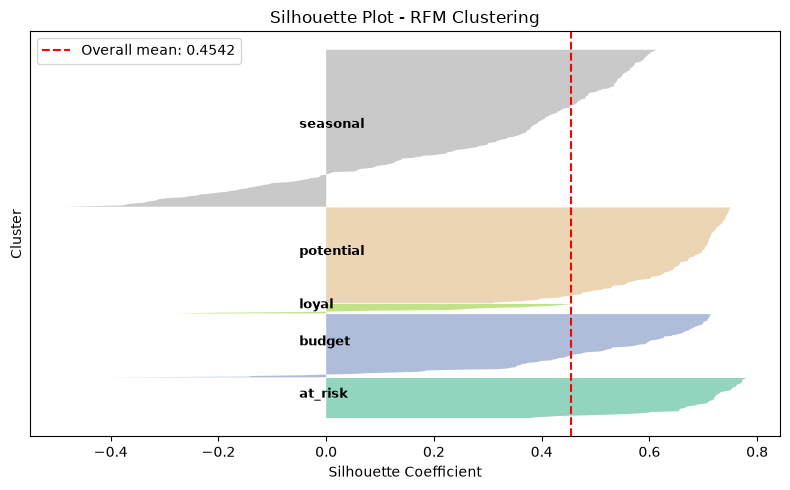

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

y_lower = 0
colors = plt.cm.Set2(np.linspace(0, 1, len(label_map)))

for seg_name, seg_idx in sorted(label_map.items(), key=lambda x: x[1]):
    mask = labels_numeric == seg_idx
    vals = np.sort(sample_silhouette_values[mask])
    size = vals.shape[0]

    ax.fill_betweenx(
        np.arange(y_lower, y_lower + size),
        0, vals,
        facecolor=colors[seg_idx], edgecolor='none', alpha=0.7
    )

    ax.text(-0.05, y_lower + size / 2, seg_name, fontsize=9, fontweight='bold')
    y_lower += size

ax.axvline(x=overall_silhouette, color='red', linestyle='--', linewidth=1.5,
           label=f'Overall mean: {overall_silhouette:.4f}')

ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot - RFM Clustering')
ax.legend(loc='best')
ax.set_yticks([])

plt.tight_layout()
plt.show()

## 7. Ringkasan

In [16]:
print('=' * 55)
print('        RINGKASAN EVALUASI KUALITAS CLUSTER')
print('=' * 55)
print(f'  Jumlah pelanggan         : {len(df)}')
print(f'  Jumlah cluster           : {len(unique_segments)}')
print(f'  Overall Silhouette Score : {overall_silhouette:.4f}')
print(f'  Davies-Bouldin Index     : {dbi:.4f}')
print()
print('  Mean Silhouette per cluster:')
for _, row in df_per_cluster.iterrows():
    bar_len = int(row['Mean Silhouette'] * 20) if row['Mean Silhouette'] > 0 else 0
    bar = '#' * max(bar_len, 0)
    print(f'    {row["Segment"]:>12s} ({row["Jumlah"]:>3d} anggota): {row["Mean Silhouette"]:+.4f}  {bar}')
print()
print('Interpretasi:')
print('  Silhouette [-1,1] — ideal > 0.5, semakin tinggi semakin baik')
print('  DBI >= 0         — ideal < 1.0, semakin rendah semakin baik')
print('=' * 55)

        RINGKASAN EVALUASI KUALITAS CLUSTER
  Jumlah pelanggan         : 543
  Jumlah cluster           : 5
  Overall Silhouette Score : 0.4542
  Davies-Bouldin Index     : 0.6203

  Mean Silhouette per cluster:
         at_risk ( 60 anggota): +0.6874  #############
          budget ( 94 anggota): +0.4975  #########
           loyal ( 15 anggota): +0.2076  ####
       potential (142 anggota): +0.6419  ############
        seasonal (232 anggota): +0.2773  #####

Interpretasi:
  Silhouette [-1,1] — ideal > 0.5, semakin tinggi semakin baik
  DBI >= 0         — ideal < 1.0, semakin rendah semakin baik
